In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")
from src import *

Cupy Available= 1


In [5]:
checkpoints = {
    "dft1d_15": "20251118-1205-synthetic_deepcad_15",
    "dft1d_150": "20251118-1221-synthetic_deepcad_150",
    "dct3d_15": "20251218-1607-synthetic_deepcad_15",
    "dct3d_150": "20251202-0835-synthetic_deepcad_150",
}

In [13]:
dataset = "synthetic"
max_frames = 1000
denoiser="noise2noise"
variant = ""
method = "dft1d_15"
avg_win = None
checkpoint = checkpoints[method]

x = Recording(f"dataset/{dataset}/x.tif", norm=True, max_frames=max_frames).np
deepcad = Recording(f"dataset/{dataset}/{denoiser}{variant}.tif", norm=True, max_frames=max_frames).np
gt = Recording(f"dataset/{dataset}/gt.tif", norm=True, max_frames=max_frames).np
f2c_grid = Recording(f"results/{dataset}/{denoiser}{variant}{avg_win or ''}/grid_{method.split("_")[0]}.tiff", max_frames=max_frames)
f2c_net = Recording(f"results/{dataset}/{denoiser}{variant}{avg_win or ''}/{checkpoint}.tiff", max_frames=max_frames)
metrics=pd.read_json(f"results/{dataset}/{denoiser}{variant}{avg_win or ''}/metrics.json")

In [9]:
# deepcad = deepcad.normalized
# gt = gt.normalized
f2c_grid = np.clip(f2c_grid.np, 0, 1)
f2c_net = np.clip(f2c_net.np, 0, 1)

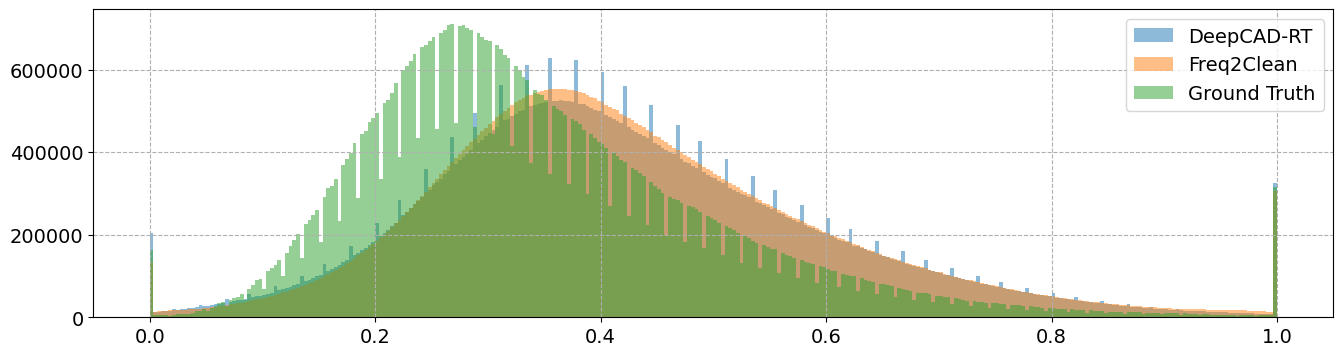

In [10]:
ax = pd.Series(deepcad.flatten()[::4]).hist(bins=300, alpha=0.5, figsize=(16, 4), label="DeepCAD-RT")
pd.Series(f2c_net.flatten()[::4]).hist(bins=300, alpha=0.5, ax=ax, label="Freq2Clean")
pd.Series(gt.flatten()[::4]).hist(bins=300, alpha=0.5, ax=ax, label="Ground Truth")
plt.legend();

The distribution is aligned, no need to *normalize* `f2c_grid` and `f2c_net`.

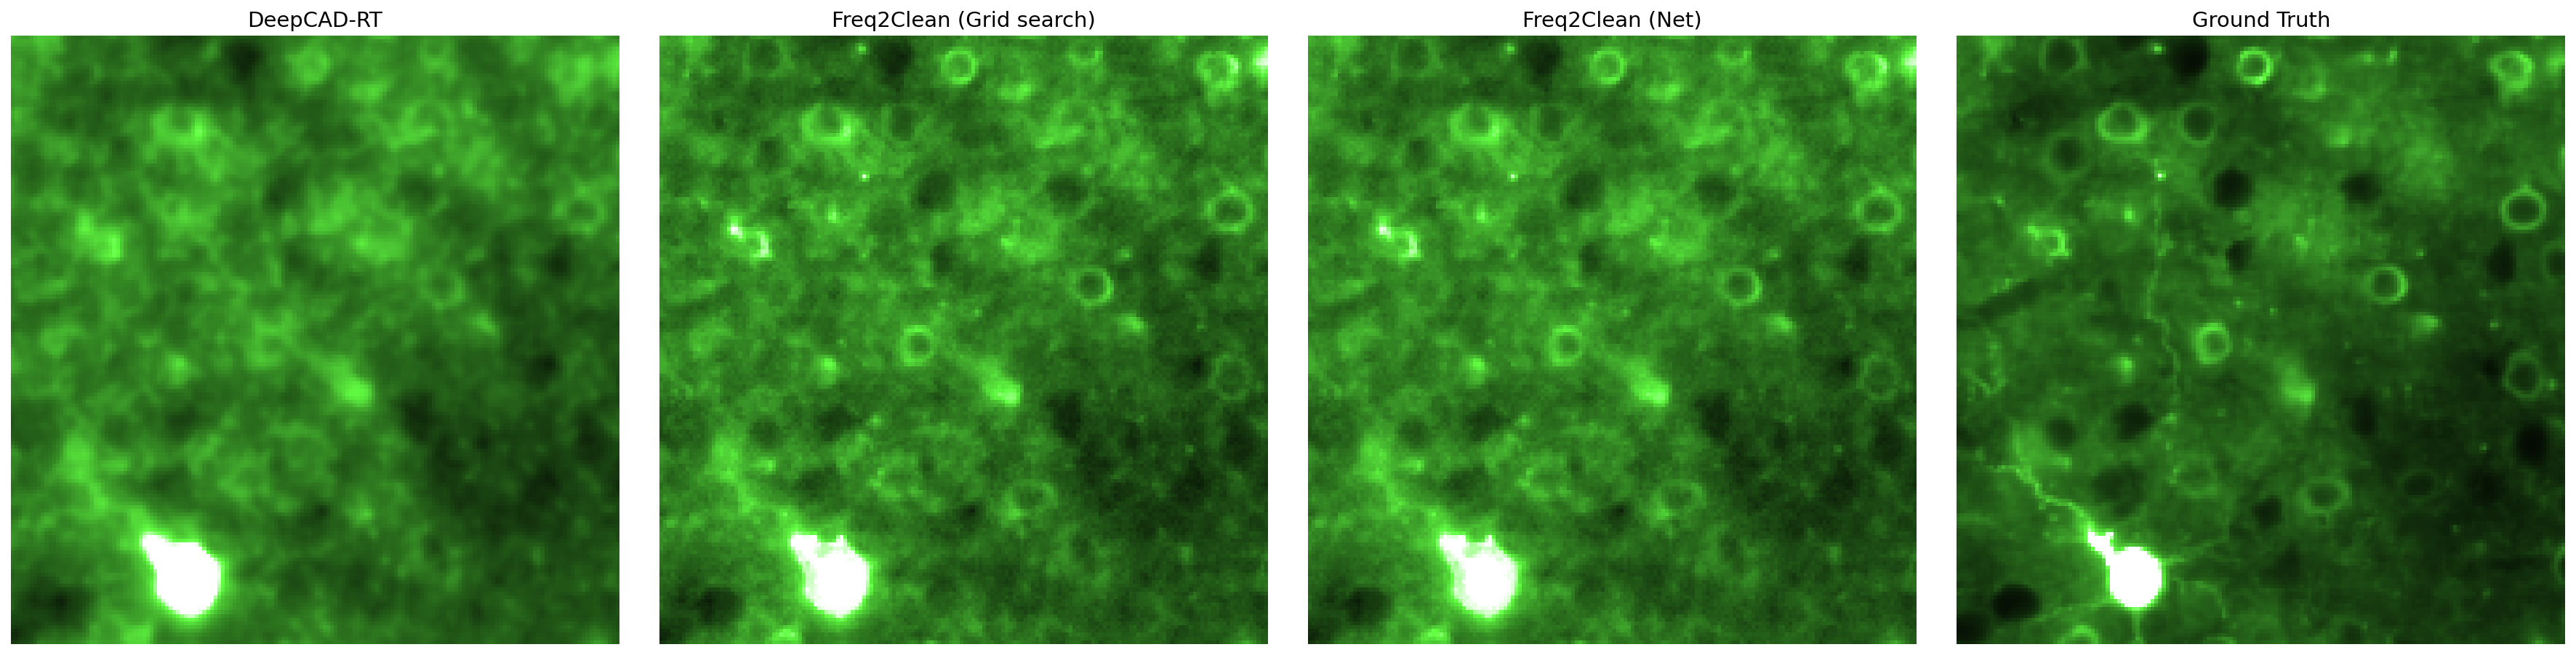

In [12]:
frame = random.randrange(gt.shape[0])
imshow(
    {
        "DeepCAD-RT": deepcad[frame],
        "Freq2Clean (Grid search)": f2c_grid[frame],
        "Freq2Clean (Net)": f2c_net[frame],
        "Ground Truth": gt[frame],
    },
    size=6,
    zoom=3,
    vrange=(0,1)
)

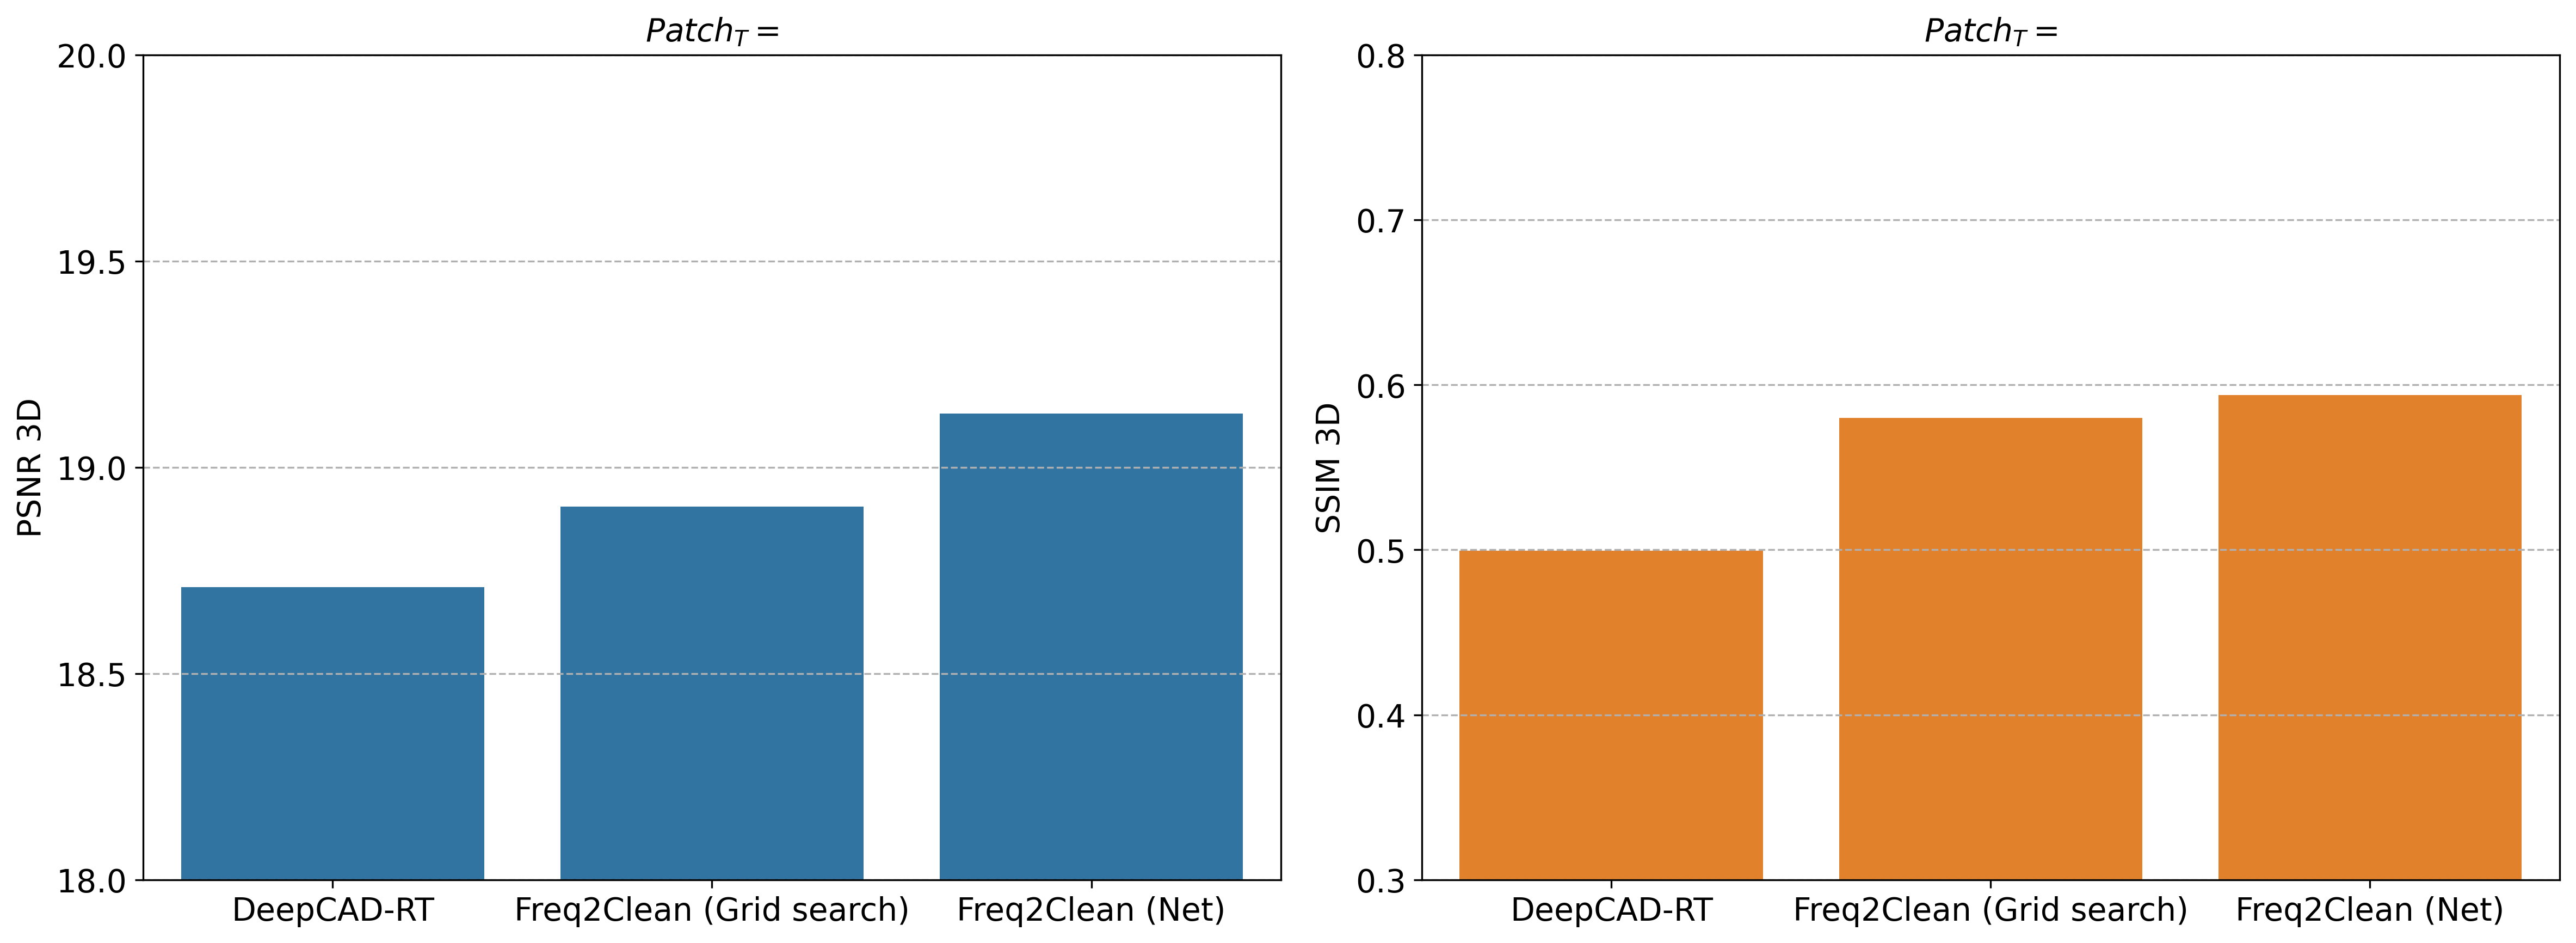

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
barchart(
    {
        "DeepCAD-RT": metrics[denoiser]["psnr3d"],
        "Freq2Clean (Grid search)": metrics[f"grid_{method.split("_")[0]}"]["psnr3d"],
        "Freq2Clean (Net)": metrics[checkpoints[method]]["psnr3d"],
    },
    bounds=(18, 20),
    yaxis="PSNR 3D",
    ysteps=4,
    color="tab:blue",
    title=f"$Patch_T={variant[1:]}$",
    ax=axs[0],
)
barchart(
    {
        "DeepCAD-RT": metrics[denoiser]["ssim3d"],
        "Freq2Clean (Grid search)": metrics[f"grid_{method.split("_")[0]}"]["ssim3d"],
        "Freq2Clean (Net)": metrics[checkpoints[method]]["ssim3d"],
    },
    bounds=(0.3, 0.8),
    yaxis="SSIM 3D",
    ysteps=5,
    color="tab:orange",
    title=f"$Patch_T={variant[1:]}$",
    ax=axs[1],
)

The Freq2Clean(net) generalizes *quite* good. When I use the variant `150` on the dataset `15` and viceversa, it performs *slightly* worse than the version trainined for the same dataset.